In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X = np.array(X)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [4]:
y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [183]:
neural_net = NeuralNet((28**2, 256, 10), learning_rate=0.001, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].weights = neural_net.layers[0].initialize("He")
neural_net.layers[-1].activation_method="softmax"
epochs = 10
losses, y_pred = neural_net.train(X_train[:],
                                  y_train[:],
                                  epochs,
                                  batch_size = 64,
                                  validate=(X_test, y_test),
                                  categorical=True,
                                  lr_scheduling=True,
                                  dropout=True,
                                  noise_normalization=True)


EPOCH: 1    LOSS: 0.0512237    LOSS CHANGE: 0    TEST ACCURACY: 0.942    TEST ACCURACY CHANGE: 0.942
EPOCH: 2    LOSS: 0.0246464    LOSS CHANGE: -0.02658    TEST ACCURACY: 0.962    TEST ACCURACY CHANGE: 0.0203
EPOCH: 3    LOSS: 0.0179098    LOSS CHANGE: -0.006737    TEST ACCURACY: 0.97    TEST ACCURACY CHANGE: 0.00729
EPOCH: 4    LOSS: 0.0142251    LOSS CHANGE: -0.003685    TEST ACCURACY: 0.975    TEST ACCURACY CHANGE: 0.00536
EPOCH: 5    LOSS: 0.0117327    LOSS CHANGE: -0.002492    TEST ACCURACY: 0.975    TEST ACCURACY CHANGE: 0.000357
EPOCH: 6    LOSS: 0.00998653    LOSS CHANGE: -0.001746    TEST ACCURACY: 0.975    TEST ACCURACY CHANGE: -0.000571
EPOCH: 7    LOSS: 0.00883978    LOSS CHANGE: -0.001147    TEST ACCURACY: 0.976    TEST ACCURACY CHANGE: 0.00157
EPOCH: 8    LOSS: 0.00794003    LOSS CHANGE: -0.0008998    TEST ACCURACY: 0.973    TEST ACCURACY CHANGE: -0.00293
EPOCH: 9    LOSS: 0.00743677    LOSS CHANGE: -0.0005033    TEST ACCURACY: 0.978    TEST ACCURACY CHANGE: 0.00414
EPOC

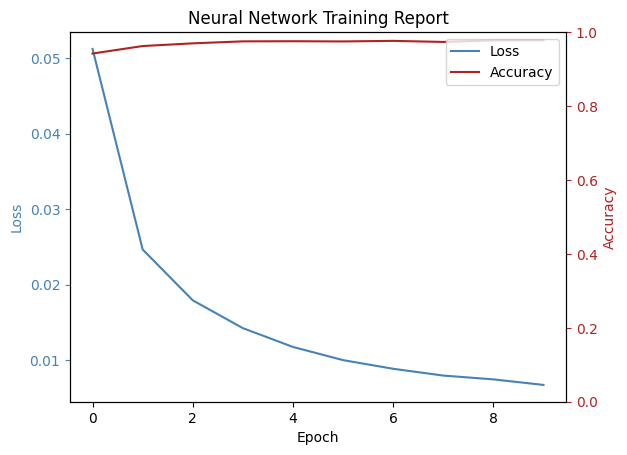

In [184]:
graphics.plot_report(neural_net)

In [185]:
neural_net.export("MNIST_net.csv")

Neural Network exported to MNIST_net.csv


In [186]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X_test)
y_pred_accuracy = np.where(y_pred > 0.5, 1, 0)

Accuracy: 0.9777142857142858


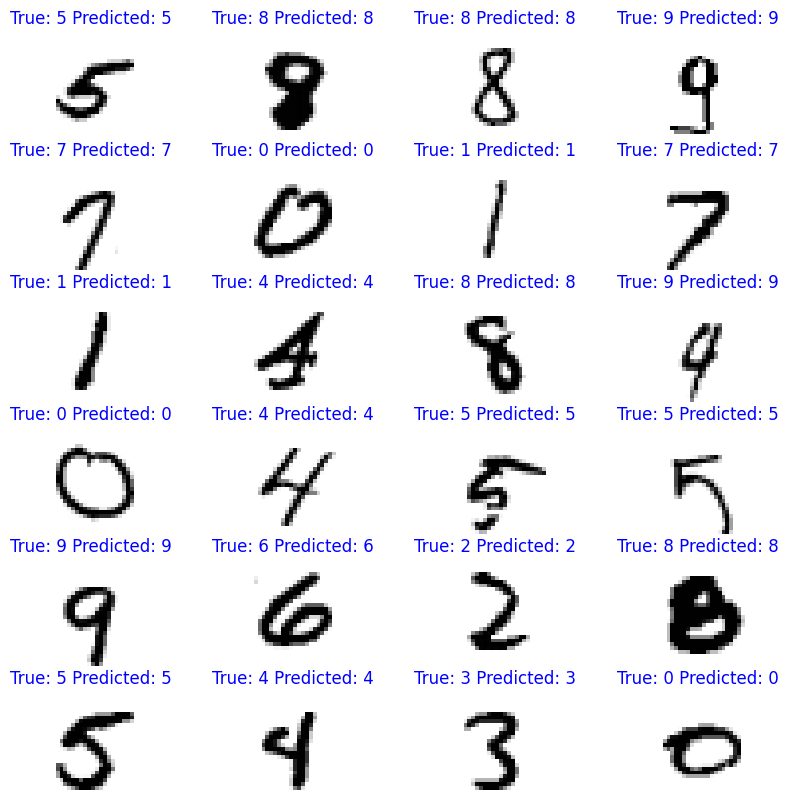

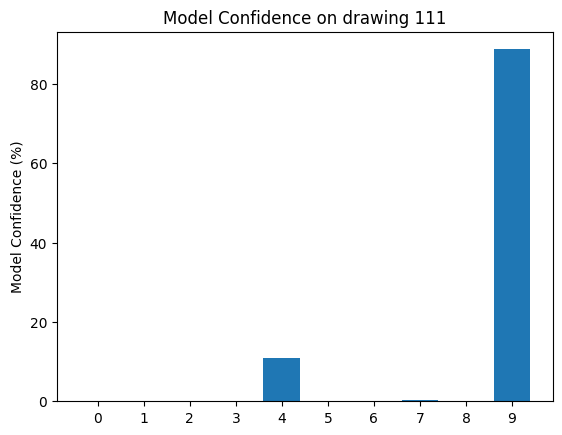

Prediction: [1.88189718e-07 1.83991640e-04 5.74768857e-09 8.97303211e-07
 1.09600586e-01 6.55470627e-08 5.76421596e-10 3.08711048e-03
 2.72517469e-09 8.87127152e-01]


In [187]:
print(f"Accuracy: {accuracy_score(y_pred_accuracy, y_test)}")

def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 6
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(24):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i+100, y_test.argmax(axis=1)[i+100], y_pred.argmax(axis=1)[i+100])
plt.show()
plt.title(f"Model Confidence on drawing {11+100}")
plt.ylabel("Model Confidence (%)")
plt.bar(np.arange(10), 100*y_pred[11+100].flatten())
plt.xticks(np.arange(10))
plt.show()
print(f"Prediction: {y_pred[11+100]}")

Pred: [[7.36894919e-13 2.05529042e-19 6.83638819e-07 9.99999138e-01
  9.35341752e-27 4.97259469e-08 1.28625623e-07 9.94671198e-21
  7.55888936e-12 6.27608900e-22]]


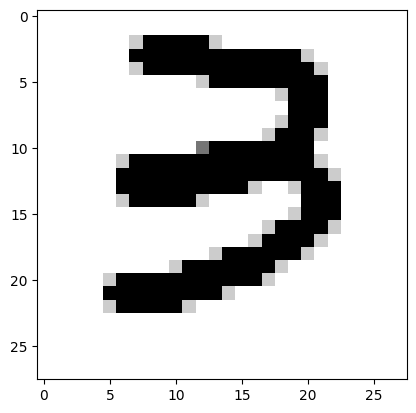

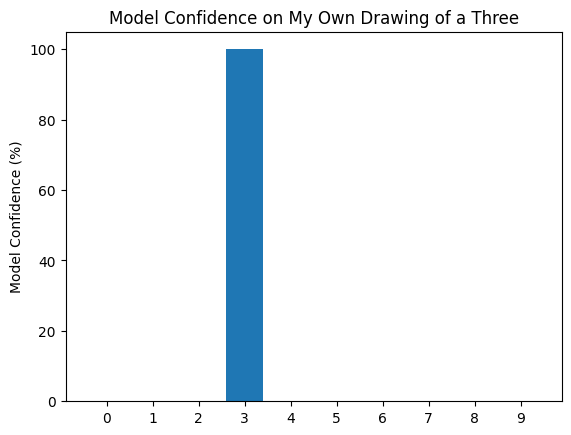

In [188]:
# can it predict my own writing?

my_three = plt.imread('three.png')[:, :28, 0]
X_my = np.array([(1 - my_three).flatten()])
y_pred_my = neural_net.predict(X_my)
print(f"Pred: {y_pred_my}")
plt.imshow(my_three, cmap="gray")
plt.show()
plt.title("Model Confidence on My Own Drawing of a Three")
plt.ylabel("Model Confidence (%)")
plt.bar(np.arange(10), 100*y_pred_my.flatten())
plt.xticks(np.arange(10))
plt.show()